In [1]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
train_path = r"C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 2\DataSets\POS tagging dataset\train.csv"
test_path = r"C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 2\DataSets\POS tagging dataset\test.csv"

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)
# print(train_df.columns)
# print(test_df.columns)

In [3]:
# 3. PREPROCESS
# =========================
def preprocess(df):
    sentences = df['Sentence'].astype(str).str.lower().tolist()
    tags = df['Tags'].astype(str).tolist()

    tokenized_sent = [s.split() for s in sentences]
    tokenized_tags = [t.split() for t in tags]

    return tokenized_sent, tokenized_tags

train_sent, train_tags = preprocess(train_df)
test_sent, test_tags   = preprocess(test_df)

In [4]:
# 4. BUILD VOCAB
word2idx = {"<PAD>":0, "<UNK>":1}
tag2idx  = {"<PAD>":0}

for sent in train_sent:
    for word in sent:
        if word not in word2idx:
            word2idx[word] = len(word2idx)

for tag_seq in train_tags:
    for tag in tag_seq:
        if tag not in tag2idx:
            tag2idx[tag] = len(tag2idx)

idx2tag = {v:k for k,v in tag2idx.items()}

In [5]:
# 5. LOAD GLOVE
# =========================
def load_glove(path):
    glove = {}
    with open(path, encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vec = np.asarray(values[1:], dtype='float32')
            glove[word] = vec
    return glove

glove_path = r"C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 2\glove.6B\glove.6B.200d.txt"
glove = load_glove(glove_path)

In [6]:
def create_embedding_matrix(word2idx, glove, dim=200):
    matrix = np.zeros((len(word2idx), dim))

    for word, idx in word2idx.items():
        if word in glove:
            matrix[idx] = glove[word]
        else:
            matrix[idx] = np.random.normal(scale=0.6, size=(dim,))
    
    return torch.tensor(matrix, dtype=torch.float32)

embedding_matrix = create_embedding_matrix(word2idx, glove)

In [7]:
# 6. DATASET
# =========================
MAX_LEN = 50

class POSDataset(Dataset):
    def __init__(self, sentences, tags):
        self.sentences = sentences
        self.tags = tags

    def __len__(self):
        return len(self.sentences)

    def __getitem__(self, idx):
        words = self.sentences[idx]
        tags  = self.tags[idx]

        word_ids = [word2idx.get(w, word2idx['<UNK>']) for w in words]
        tag_ids  = [tag2idx[t] for t in tags]

        # Padding
        word_ids = word_ids[:MAX_LEN] + [0]*(MAX_LEN - len(word_ids))
        tag_ids  = tag_ids[:MAX_LEN] + [0]*(MAX_LEN - len(tag_ids))

        return torch.tensor(word_ids), torch.tensor(tag_ids)


train_dataset = POSDataset(train_sent, train_tags)
test_dataset  = POSDataset(test_sent, test_tags)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32)

In [8]:
# 7. MODEL
# =========================
class RNNModel(nn.Module):
    def __init__(self, embedding_matrix, tag_size):
        super().__init__()

        vocab_size, embed_dim = embedding_matrix.shape

        self.embedding = nn.Embedding.from_pretrained(embedding_matrix, freeze=True)
        self.rnn = nn.RNN(embed_dim, 25, batch_first=True)
        self.fc = nn.Linear(25, tag_size)

    def forward(self, x):
        x = self.embedding(x)
        out, _ = self.rnn(x)
        out = self.fc(out)
        return out


model = RNNModel(embedding_matrix, len(tag2idx))

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [9]:
# 8. TRAIN
# =========================
def train(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:
        optimizer.zero_grad()

        outputs = model(x)

        outputs_flat = outputs.view(-1, outputs.shape[-1])
        y_flat = y.view(-1)

        loss = criterion(outputs_flat, y_flat)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Accuracy calculation
        preds = torch.argmax(outputs, dim=-1)

        preds = preds.view(-1)
        y_flat = y_flat

        mask = y_flat != 0  # ignore padding
        preds = preds[mask]
        y_flat = y_flat[mask]

        correct += (preds == y_flat).sum().item()
        total += y_flat.shape[0]

    accuracy = correct / total
    error = 1 - accuracy

    return total_loss / len(loader), accuracy, error

In [10]:
def evaluate(model, loader):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            preds = torch.argmax(outputs, dim=-1)

            preds = preds.view(-1).numpy()
            y = y.view(-1).numpy()

            mask = y != 0
            preds = preds[mask]
            y = y[mask]

            all_preds.extend(preds)
            all_labels.extend(y)

    # ✅ Calculate overall accuracy
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy = np.sum(all_preds == all_labels) / len(all_labels)
    error = 1 - accuracy

    print("\n===== TEST RESULTS =====")
    print(f"Overall Accuracy : {accuracy:.4f}")
    print(f"Overall Error    : {error:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

Epoch 1
Loss     : 1.5909
Accuracy : 0.5694
Error    : 0.4306
------------------------------
Epoch 2
Loss     : 0.7981
Accuracy : 0.7607
Error    : 0.2393
------------------------------
Epoch 3
Loss     : 0.6067
Accuracy : 0.8098
Error    : 0.1902
------------------------------
Epoch 4
Loss     : 0.5207
Accuracy : 0.8349
Error    : 0.1651
------------------------------
Epoch 5
Loss     : 0.4687
Accuracy : 0.8518
Error    : 0.1482
------------------------------
Epoch 6
Loss     : 0.4319
Accuracy : 0.8627
Error    : 0.1373
------------------------------
Epoch 7
Loss     : 0.4030
Accuracy : 0.8712
Error    : 0.1288
------------------------------
Epoch 8
Loss     : 0.3815
Accuracy : 0.8782
Error    : 0.1218
------------------------------
Epoch 9
Loss     : 0.3630
Accuracy : 0.8831
Error    : 0.1169
------------------------------
Epoch 10
Loss     : 0.3479
Accuracy : 0.8873
Error    : 0.1127
------------------------------

===== TEST RESULTS =====
Overall Accuracy : 0.8591
Overall Error    

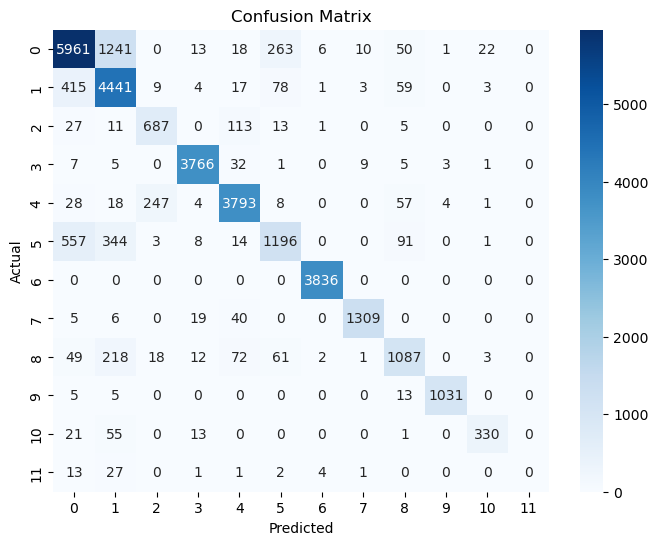

In [11]:
# 10. RUN
# =========================
EPOCHS = 10

for epoch in range(EPOCHS):
    loss, acc, err = train(model, train_loader)

    print(f"Epoch {epoch+1}")
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Error    : {err:.4f}")
    print("-"*30)

evaluate(model, test_loader)